# ML-10 — Content Action Playbook



This notebook turns the validated refresh ranking into a human-reviewed editorial queue. It does **not** refit the model. Instead, it adds public-safe reason codes, content archetypes, action guidance, review-cost estimates, and monitoring rules to the generated 30,000-row queue.



The model score is decision support, not proof that a refresh will improve traffic. The observed decline label is retained only for retrospective evaluation and is removed from operational reason codes and action rules.

## 1. Ranked actions with leakage-safe reason codes



The queue is ranked by the already validated combined score. Before assigning actions, I remove `declining_with_demand` because it is derived from the evaluation label. The safe playbook reasons use model probability and observable page signals only. The displayed preview omits pseudonymous IDs, while the exported operational queue keeps them for approved joins and human lookup.

In [10]:
from pathlib import Path

import json



import matplotlib.pyplot as plt

import numpy as np

import pandas as pd



SEED = 42

LABEL_DERIVED_REASONS = {"declining_with_demand"}



candidates = [Path.cwd(), *Path.cwd().parents]

root = next(

    (

        candidate

        for candidate in candidates

        if (candidate / "outputs" / "refresh_queue_sample.csv").exists()

    ),

    None,

)



if root is not None:

    full_queue_path = root / "outputs" / "refresh_queue.csv"

    QUEUE_SOURCE = full_queue_path if full_queue_path.exists() else root / "outputs" / "refresh_queue_sample.csv"

    OUTPUT_DIR = root / "work" / "outputs"

else:

    QUEUE_SOURCE = (

        "https://raw.githubusercontent.com/thany-8/content-refresh-prioritizer/"

        "main/outputs/refresh_queue_sample.csv"

    )

    OUTPUT_DIR = Path.cwd() / "work_outputs"



queue = pd.read_csv(QUEUE_SOURCE).sort_values("final_rank").reset_index(drop=True)

assert not queue.empty

assert queue["final_rank"].is_monotonic_increasing

assert queue["content_id"].is_unique



def safe_reasons(reason_text):

    reasons = [reason for reason in str(reason_text).split("|") if reason and reason != "nan"]

    safe = [reason for reason in reasons if reason not in LABEL_DERIVED_REASONS]

    return "|".join(dict.fromkeys(safe)) if safe else "general_refresh_review"



def assign_action(reason_text):

    reasons = set(str(reason_text).split("|"))

    if "thin_visible_page" in reasons:

        return "expand_and_refresh"

    if "ctr_review_candidate" in reasons and "model_decline_risk" in reasons:

        return "refresh_and_review_ctr"

    if "engagement_review_candidate" in reasons and "model_decline_risk" in reasons:

        return "refresh_and_review_engagement"

    if reasons.intersection({"model_decline_risk", "stale_visible_page", "visible_model_opportunity"}):

        return "refresh"

    return "monitor"



queue["decision_reason_codes"] = queue["final_reason_codes"].map(safe_reasons)

queue["recommended_action"] = queue["decision_reason_codes"].map(assign_action)

assert not queue["decision_reason_codes"].str.contains("declining_with_demand", regex=False).any()



preview_columns = [

    "final_rank", "final_refresh_score", "confidence", "recommended_action",

    "decision_reason_codes", "impressions_90d", "sessions_90d", "avg_position", "ctr",

]

public_preview = queue[preview_columns].head(15).copy()

public_preview["decision_reason_codes"] = public_preview["decision_reason_codes"].str.replace("|", ", ", regex=False)

print(f"Loaded {len(queue):,} ranked pages from {QUEUE_SOURCE}.")

public_preview.round({"final_refresh_score": 1, "avg_position": 1, "ctr": 2})

Loaded 30,000 ranked pages from /Users/thany/Documents/Development/content-refresh-prioritizer/outputs/refresh_queue.csv.


,final_rank,final_refresh_score,confidence,recommended_action,decision_reason_codes,impressions_90d,sessions_90d,avg_position,ctr
0,1,81.6,high,refresh_and_review_ctr,"low_ctr_visible_page, low_engagement_visible_p...",12834,66,6.8,0.05
1,2,81.4,high,refresh_and_review_ctr,"low_ctr_visible_page, model_decline_risk, visi...",8064,23,3.8,0.07
2,3,81.4,medium,refresh_and_review_ctr,"low_ctr_visible_page, model_decline_risk, visi...",2498,9,10.1,0.00
3,4,81.0,high,refresh_and_review_ctr,"low_ctr_visible_page, model_decline_risk, visi...",13790,27,8.2,0.12
4,5,80.9,medium,refresh_and_review_ctr,"low_ctr_visible_page, model_decline_risk, visi...",3393,5,3.6,0.09
5,6,80.8,high,refresh_and_review_ctr,"low_ctr_visible_page, model_decline_risk, visi...",5811,14,6.4,0.07
6,7,80.6,high,refresh_and_review_ctr,"low_ctr_visible_page, model_decline_risk, visi...",1622,20,3.1,0.12
7,8,80.4,high,refresh_and_review_ctr,"low_ctr_visible_page, model_decline_risk, visi...",2621,10,12.8,0.00
8,9,80.4,medium,refresh_and_review_ctr,"low_ctr_visible_page, model_decline_risk, visi...",1597,5,2.7,0.13
9,10,80.3,medium,refresh,"model_decline_risk, visible_model_opportunity",3867,5,27.5,0.05


## 2. Archetype → action mapping and the decay/refresh insight



A score alone does not tell an editor what to inspect. Each page is therefore assigned one primary archetype from its observable reason codes. The mapping is deterministic and readable: CTR opportunity, engagement friction, thin visible content, stale visible content, aging page-one content, visible model risk, model-only risk, or monitor.



**Decay/refresh insight:** observed decline and refresh value are not the same thing. A declining page with no meaningful demand may be a poor use of editorial time, while a still-visible page with an actionable CTR, engagement, freshness, or coverage issue may deserve review. The playbook therefore combines ranking strength, visibility, and a specific human-checkable issue. The label is used below only to audit how archetypes behaved in this snapshot; it never selects the action.

In [11]:
def assign_archetype(reason_text):

    reasons = set(str(reason_text).split("|"))

    if "thin_visible_page" in reasons:

        return "thin_visible_content"

    if "ctr_review_candidate" in reasons and "model_decline_risk" in reasons:

        return "visible_ctr_opportunity"

    if "engagement_review_candidate" in reasons and "model_decline_risk" in reasons:

        return "engagement_friction"

    if "stale_visible_page" in reasons:

        return "stale_visible_content"

    if "page_one_decay_risk" in reasons:

        return "aging_page_one_content"

    if "visible_model_opportunity" in reasons:

        return "visible_model_risk"

    if "model_decline_risk" in reasons:

        return "model_only_risk"

    return "monitor_or_low_evidence"



queue["archetype"] = queue["decision_reason_codes"].map(assign_archetype)



archetype_action_map = pd.DataFrame(

    [

        (1, "visible_ctr_opportunity", "refresh_and_review_ctr", "Check live intent, title, snippet, and SERP context."),

        (2, "engagement_friction", "refresh_and_review_engagement", "Check intent satisfaction and analytics quality."),

        (3, "thin_visible_content", "expand_and_refresh", "Confirm a real coverage gap before adding content."),

        (4, "stale_visible_content", "refresh", "Verify facts, freshness, and current business priority."),

        (5, "aging_page_one_content", "refresh", "Protect useful visibility after checking ranking context."),

        (6, "visible_model_risk", "refresh", "Inspect the page for a concrete issue before editing."),

        (7, "model_only_risk", "monitor", "Seek stronger observable evidence before spending effort."),

        (8, "monitor_or_low_evidence", "monitor", "Defer unless business context raises priority."),

    ],

    columns=["priority", "archetype", "default_action", "human_next_step"],

)



action_lookup = archetype_action_map.set_index("archetype")["default_action"]

queue["recommended_action"] = queue["archetype"].map(action_lookup)



# Retrospective label rates audit the mapping; they do not create it.

archetype_summary = (

    queue.groupby(["archetype", "recommended_action"], dropna=False)

    .agg(

        pages=("content_id", "size"),

        observed_decline_rate=("is_declining_label", "mean"),

        median_score=("final_refresh_score", "median"),

        median_impressions=("impressions_90d", "median"),

        high_confidence_share=("confidence", lambda values: values.eq("high").mean()),

    )

    .sort_values(["median_score", "pages"], ascending=[False, False])

    .reset_index()

)



display(archetype_action_map)

archetype_summary.round(3)

,priority,archetype,default_action,human_next_step
0,1,visible_ctr_opportunity,refresh_and_review_ctr,"Check live intent, title, snippet, and SERP co..."
1,2,engagement_friction,refresh_and_review_engagement,Check intent satisfaction and analytics quality.
2,3,thin_visible_content,expand_and_refresh,Confirm a real coverage gap before adding cont...
3,4,stale_visible_content,refresh,"Verify facts, freshness, and current business ..."
4,5,aging_page_one_content,refresh,Protect useful visibility after checking ranki...
5,6,visible_model_risk,refresh,Inspect the page for a concrete issue before e...
6,7,model_only_risk,monitor,Seek stronger observable evidence before spend...
7,8,monitor_or_low_evidence,monitor,Defer unless business context raises priority.


,archetype,recommended_action,pages,observed_decline_rate,median_score,median_impressions,high_confidence_share
0,stale_visible_content,refresh,5,0.800,71.427,4429.0,0.200
1,engagement_friction,refresh_and_review_engagement,984,0.860,69.345,4804.0,0.848
2,visible_ctr_opportunity,refresh_and_review_ctr,3341,0.835,67.435,1681.0,0.431
3,visible_model_risk,refresh,4927,0.664,60.821,2541.0,0.214
4,model_only_risk,monitor,2354,0.831,58.851,202.0,0.000
5,aging_page_one_content,refresh,6528,0.487,52.022,1108.5,0.041
6,thin_visible_content,expand_and_refresh,82,0.537,50.650,708.5,0.098
7,monitor_or_low_evidence,monitor,11779,0.354,41.139,154.0,0.000


## 3. Human review, relative value, and capacity

Review effort is scarce, so rank alone is not the policy. The **relative value proxy** combines within-queue percentiles for impressions (60%), sessions (25%), and the leakage-safe baseline score (15%). It measures relative exposure/opportunity in this queue only; it is not revenue, conversion value, expected uplift, or a causal estimate. Tiers use the observed queue distribution: standard (bottom 50%), elevated (50th-80th), high (80th-95th), and highest (top 5%).

Estimated review minutes are planning assumptions by action, with small adjustments for long or missing-length pages. A 20-reviewer-hour weekly scenario walks the ranked queue in order and creates capacity batches from cumulative estimated effort. A false positive consumes editorial time and can introduce unnecessary changes; a false negative delays review and learning for a page that may later decline. Human context can override the proxy, but the reason should be documented.

Before acting, review page purpose, current search results, seasonality, conversion role, previous edits, tracking quality, effort, and relative value. Publication, deletion, redirects, metadata/link changes, client communication, model-only edits, cross-client disclosure, and traffic/revenue promises remain explicitly human-only.

In [12]:
# Relative value is an exposure/opportunity proxy, not revenue or causal uplift.
queue["relative_value_proxy"] = (
    0.60 * queue["impressions_90d"].rank(pct=True)
    + 0.25 * queue["sessions_90d"].rank(pct=True)
    + 0.15 * queue["baseline_refresh_score"].rank(pct=True)
).round(4)
queue["relative_value_tier"] = pd.qcut(
    queue["relative_value_proxy"],
    q=[0, 0.50, 0.80, 0.95, 1.0],
    labels=["standard", "elevated", "high", "highest"],
    duplicates="drop",
).astype(str)

base_review_minutes = {
    "monitor": 5,
    "refresh_and_review_ctr": 20,
    "refresh_and_review_engagement": 25,
    "refresh": 35,
    "expand_and_refresh": 60,
}
queue["review_minutes"] = queue["recommended_action"].map(base_review_minutes).astype(int)
queue.loc[queue["word_count"].fillna(0).gt(2_000) & queue["recommended_action"].ne("monitor"), "review_minutes"] += 10
queue.loc[queue["word_count"].isna() & queue["recommended_action"].ne("monitor"), "review_minutes"] += 5

WEEKLY_REVIEW_CAPACITY_MINUTES = 20 * 60
queue["capacity_batch"] = (
    (queue["review_minutes"].cumsum().sub(1) // WEEKLY_REVIEW_CAPACITY_MINUTES) + 1
).astype(int)
queue["capacity_status"] = np.where(queue["capacity_batch"].eq(1), "current_batch", "backlog")

value_distribution = (
    queue.groupby("relative_value_tier", observed=True)
    .agg(
        pages=("content_id", "size"),
        median_impressions_90d=("impressions_90d", "median"),
        median_sessions_90d=("sessions_90d", "median"),
        median_review_minutes=("review_minutes", "median"),
    )
    .reindex(["standard", "elevated", "high", "highest"])
    .reset_index()
)
current_batch = queue.loc[queue["capacity_batch"].eq(1)]

review_policy = {
    "value_proxy": {
        "definition": "Queue-relative exposure/opportunity proxy: 60% impressions percentile, 25% sessions percentile, and 15% baseline-score percentile.",
        "interpretation": "A triage aid within this queue; not revenue, conversion value, or expected uplift.",
        "tiers": "Observed queue percentiles: standard 0-50%, elevated 50-80%, high 80-95%, highest 95-100%.",
    },
    "effort_estimate": {
        "base_minutes_by_action": base_review_minutes,
        "adjustments": "+10 minutes above 2,000 words; +5 minutes when word count is unavailable; estimates are planning assumptions, not measured labor time.",
    },
    "error_costs": {
        "false_positive": "Consumes review/edit time and may introduce unnecessary content or search-risk changes; require stronger evidence for long, high-value, or strategically sensitive pages.",
        "false_negative": "Delays review of a page that later shows a material decline and loses a chance to learn; prioritize monitoring for high-exposure pages even when action evidence is weak.",
        "tradeoff": "Use the ranked queue to allocate scarce review, but let business context override the proxy after documenting the reason.",
    },
    "capacity_plan": {
        "scenario_minutes_per_week": WEEKLY_REVIEW_CAPACITY_MINUTES,
        "batch_rule": "Walk the full ranked queue in order and start a new batch whenever cumulative estimated review time exceeds capacity.",
        "current_batch_pages": int(len(current_batch)),
        "current_batch_estimated_minutes": int(current_batch["review_minutes"].sum()),
    },
    "required_checks": [
        "page purpose and business priority",
        "current search-result and intent context",
        "seasonality or campaign timing",
        "conversion role and internal dependencies",
        "tracking completeness and previous edits",
        "whether the estimated effort and relative value justify this batch",
    ],
    "never_automate": [
        "publish, delete, or substantially rewrite content",
        "redirect, canonicalize, or change URL structure",
        "change titles, metadata, links, or structured data without human approval",
        "act on model-only risk without a concrete observable issue",
        "suppress strategically important content because its proxy tier is low",
        "contact clients or expose one client's records to another",
        "promise traffic, conversion, or revenue recovery",
    ],
}

assert queue["relative_value_proxy"].between(0, 1).all()
assert queue["review_minutes"].gt(0).all()
assert current_batch["review_minutes"].sum() <= WEEKLY_REVIEW_CAPACITY_MINUTES

display(value_distribution)
pd.Series(review_policy)

,relative_value_tier,pages,median_impressions_90d,median_sessions_90d,median_review_minutes
0,standard,15001,81.0,2.0,5.0
1,elevated,8999,1880.0,14.0,35.0
2,high,4500,9361.5,56.0,35.0
3,highest,1500,36290.5,205.5,35.0


value_proxy        {'definition': 'Queue-relative exposure/opport...
effort_estimate    {'base_minutes_by_action': {'monitor': 5, 'ref...
error_costs        {'false_positive': 'Consumes review/edit time ...
capacity_plan      {'scenario_minutes_per_week': 1200, 'batch_rul...
required_checks    [page purpose and business priority, current s...
never_automate     [publish, delete, or substantially rewrite con...
dtype: object

## 4. Monitoring / retrain triggers



Monitor the queue as a workflow, not just a model score. Re-run monthly when new approved data is available. Revalidate sooner if top-50 precision falls below 0.60, the observed decline base rate moves by more than 10 percentage points, feature missingness shifts by more than 10 points, or the client/content mix changes materially.

In [13]:
monitoring_triggers = pd.DataFrame(

    [

        ("top_50_precision", "< 0.60", "Revalidate ranking and pause automatic queue promotion."),

        ("decline_base_rate", "> 10 percentage-point shift", "Recalibrate expectations and metrics."),

        ("feature_missingness", "> 10 percentage-point shift", "Audit upstream collection and imputation."),

        ("client_or_content_mix", "material change", "Repeat grouped validation before reuse."),

        ("data_age", "> 30 days", "Regenerate the queue from approved current data."),

    ],

    columns=["signal", "trigger", "response"],

)

monitoring_triggers

,signal,trigger,response
0,top_50_precision,< 0.60,Revalidate ranking and pause automatic queue p...
1,decline_base_rate,> 10 percentage-point shift,Recalibrate expectations and metrics.
2,feature_missingness,> 10 percentage-point shift,Audit upstream collection and imputation.
3,client_or_content_mix,material change,Repeat grouped validation before reuse.
4,data_age,> 30 days,Regenerate the queue from approved current data.


## 5. Operational exports and aggregate receipt

The full ranked operational queue is exported to `work/outputs/ranked_content_recommendations.csv`. It retains pseudonymous `content_id` and `client_id` only for approved lookup and joins. It excludes the retrospective label, label-derived trend, original reason codes, and original suggested action: specifically, no `is_declining_label`, `trend_direction`, `final_reason_codes`, or `suggested_action` leaves this cell.

The CSV includes rank, model/baseline scores, probability, confidence, human-reviewed action guidance, safe decision reasons, archetype, relative value tier/proxy, estimated review minutes, capacity batch, and public-safe page metrics/attributes. `action_playbook.json` is an aggregate receipt with policy assumptions and queue distributions; `archetype_mix.svg` is an aggregate reusable figure. Neither displayed tables nor the figure contain page or client identifiers.

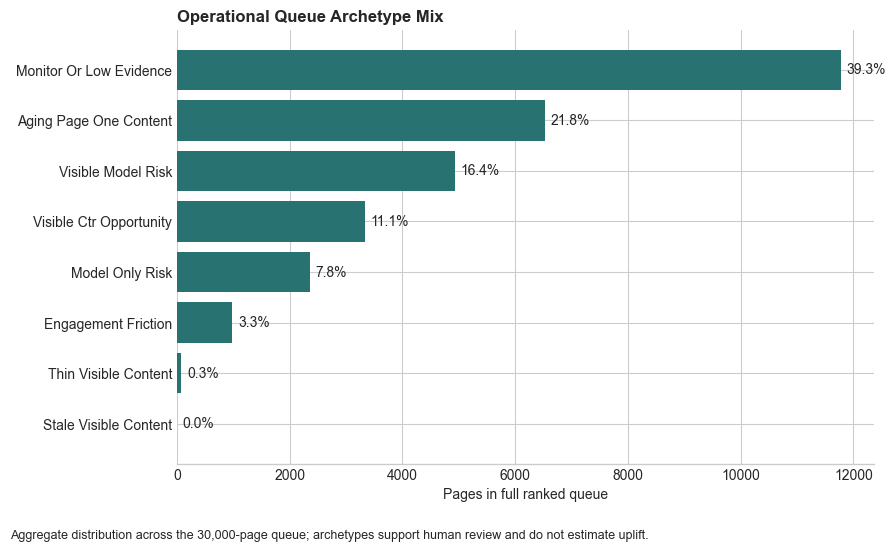

Saved 30,000 ranked recommendations to /Users/thany/Documents/Development/content-refresh-prioritizer/work/outputs/ranked_content_recommendations.csv
Saved aggregate receipt to /Users/thany/Documents/Development/content-refresh-prioritizer/work/outputs/action_playbook.json
Saved aggregate figure to /Users/thany/Documents/Development/content-refresh-prioritizer/work/outputs/archetype_mix.svg


In [14]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RANKED_QUEUE_PATH = OUTPUT_DIR / "ranked_content_recommendations.csv"
PLAYBOOK_PATH = OUTPUT_DIR / "action_playbook.json"
FIGURE_PATH = OUTPUT_DIR / "archetype_mix.svg"

operational_columns = [
    "final_rank", "content_id", "client_id", "final_refresh_score",
    "best_model_probability", "baseline_refresh_score", "confidence",
    "recommended_action", "decision_reason_codes", "archetype",
    "relative_value_proxy", "relative_value_tier", "review_minutes",
    "capacity_batch", "capacity_status", "impressions_90d", "clicks_90d",
    "sessions_90d", "avg_position", "ctr", "content_age_days",
    "days_since_last_update", "word_count", "competition_level",
    "content_type", "main_intent", "age_tier", "freshness_tier",
    "word_count_tier", "impression_tier", "position_tier",
]
ranked_export = queue[operational_columns].rename(columns={"final_rank": "rank"}).copy()
prohibited_export_columns = {
    "is_declining_label", "trend_direction", "final_reason_codes", "suggested_action"
}

assert prohibited_export_columns.isdisjoint(ranked_export.columns)
assert ranked_export["rank"].is_monotonic_increasing
assert ranked_export["content_id"].is_unique
assert len(ranked_export) == len(queue)
assert not ranked_export["decision_reason_codes"].str.contains("declining_with_demand", regex=False).any()
ranked_export.to_csv(RANKED_QUEUE_PATH, index=False)

archetype_mix = (
    queue["archetype"].value_counts().rename_axis("archetype").reset_index(name="pages")
)
archetype_mix["share"] = archetype_mix["pages"] / len(queue)
figure_data = archetype_mix.sort_values("pages")
figure_labels = figure_data["archetype"].str.replace("_", " ").str.title()

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(figure_labels, figure_data["pages"], color="#287271")
ax.bar_label(bars, labels=[f"{share:.1%}" for share in figure_data["share"]], padding=4)
ax.set_title("Operational Queue Archetype Mix", loc="left", weight="bold")
ax.set_xlabel("Pages in full ranked queue")
ax.set_ylabel("")
ax.spines[["top", "right", "left"]].set_visible(False)
fig.text(
    0.01, 0.01,
    "Aggregate distribution across the 30,000-page queue; archetypes support human review and do not estimate uplift.",
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(FIGURE_PATH, format="svg", bbox_inches="tight")
plt.show()

playbook_payload = {
    "receipt_version": 1,
    "queue_scope": "full ranked operational queue",
    "source": str(Path(QUEUE_SOURCE).relative_to(root)) if root is not None else str(QUEUE_SOURCE),
    "rows_exported": int(len(ranked_export)),
    "rank_range": [int(ranked_export["rank"].min()), int(ranked_export["rank"].max())],
    "operational_queue": str(RANKED_QUEUE_PATH.relative_to(root)) if root is not None else str(RANKED_QUEUE_PATH),
    "aggregate_figure": str(FIGURE_PATH.relative_to(root)) if root is not None else str(FIGURE_PATH),
    "excluded_sensitive_or_retrospective_fields": sorted(prohibited_export_columns),
    "action_priority": archetype_action_map.to_dict(orient="records"),
    "action_mix": {str(key): int(value) for key, value in queue["recommended_action"].value_counts().items()},
    "confidence_mix": {str(key): int(value) for key, value in queue["confidence"].value_counts().items()},
    "archetype_mix": {str(row.archetype): int(row.pages) for row in archetype_mix.itertuples()},
    "relative_value_tier_mix": {
        str(key): int(value) for key, value in queue["relative_value_tier"].value_counts().items()
    },
    "review_effort": {
        "total_estimated_minutes": int(queue["review_minutes"].sum()),
        "median_minutes_per_page": float(queue["review_minutes"].median()),
        "capacity_batches": int(queue["capacity_batch"].max()),
    },
    "review_policy": review_policy,
    "monitoring_triggers": monitoring_triggers.to_dict(orient="records"),
    "claim_boundary": "Scores, tiers, and effort estimates support review prioritization; they do not estimate causal uplift or revenue.",
}
PLAYBOOK_PATH.write_text(json.dumps(playbook_payload, indent=2) + "\n")

assert RANKED_QUEUE_PATH.exists() and RANKED_QUEUE_PATH.stat().st_size > 0
assert PLAYBOOK_PATH.exists() and PLAYBOOK_PATH.stat().st_size > 0
assert FIGURE_PATH.exists() and FIGURE_PATH.stat().st_size > 0

print(f"Saved {len(ranked_export):,} ranked recommendations to {RANKED_QUEUE_PATH}")
print(f"Saved aggregate receipt to {PLAYBOOK_PATH}")
print(f"Saved aggregate figure to {FIGURE_PATH}")

## Self-check

- [x] Loaded and ranked the full generated queue
- [x] Removed the label-derived decline reason before action/archetype assignment
- [x] Added queue-relative value tiers, estimated review effort, error costs, capacity batches, and explicit never-automate rules
- [x] Retained light monitoring and retraining triggers
- [x] Exported the full operational CSV with approved lookup IDs and without retrospective/prohibited fields
- [x] Exported an aggregate JSON receipt and ID-free SVG archetype figure
- [x] Displayed recommendations and figures omit client and content identifiers
- [x] Claims stay directional and decision-supporting; no causal uplift or revenue claim is made
- [x] All code cells executed top-to-bottom in `.venv-1` with no errors